In [1]:
import os
import sys
import json
import torch
import nltk
import re
import pandas as pd
import jsonlines
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    BertForSequenceClassification
)
from difflib import SequenceMatcher
from nltk.tokenize import sent_tokenize, word_tokenize

# ========================================================================
# 1. KONFIGURASI
# ========================================================================
CHECKPOINT_ENT_PATH = r"D:\textualentailments\modelte\BERT-20250925T085910Z-1-001\BERT\results_indobert\checkpoint-343355"
T5_MODEL_NAME = "Wikidepia/IndoT5-base-paraphrase"
DATA_FILE = r"D:\textualentailments\tempo_dataset_cleaned_TERBARU.jsonl"
OUTPUT_FILE = r"D:\textualentailments\3_final_summary_last_sentences_tempo.jsonl"
NUM_DOCS = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

d:\conda_envs\nlp_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\conda_envs\nlp_project\lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
d:\conda_envs\nlp_project\lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
W0522 17:14:47.018330 31336 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


✅ Using device: cuda


d:\conda_envs\nlp_project\lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
# ========================================================================
# 2. DOWNLOAD NLTK
# ========================================================================
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    print("📥 Downloading NLTK punkt...")
    nltk.download("punkt")

In [3]:
# ========================================================================
# 3. LOAD MODELS
# ========================================================================
print("\n🔄 Loading IndoBERT Entailment Model...")
ent_tok = AutoTokenizer.from_pretrained(CHECKPOINT_ENT_PATH, trust_remote_code=True)
ent_mdl = BertForSequenceClassification.from_pretrained(CHECKPOINT_ENT_PATH, trust_remote_code=True)
ent_mdl.to(device)
ent_mdl.eval()
print("✅ IndoBERT loaded!")

print("\n🔄 Loading IndoT5 Paraphrase Model...")
t5_tok = AutoTokenizer.from_pretrained(T5_MODEL_NAME, use_fast=False, legacy=False)
t5_mdl = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_NAME)
t5_mdl.to(device)
print("✅ IndoT5 loaded!")

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.



🔄 Loading IndoBERT Entailment Model...
✅ IndoBERT loaded!

🔄 Loading IndoT5 Paraphrase Model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


✅ IndoT5 loaded!


In [4]:
# =========================
# ENTAILMENT CHECK
# =========================
def check_entailment(premise: str, hypothesis: str):
    inputs = ent_tok(
        premise,
        hypothesis,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        logits = ent_mdl(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
    
    entailment_score = probs[0][0].item()
    predicted_label = torch.argmax(logits, dim=-1).item()
    
    return predicted_label == 0, entailment_score

In [5]:
# =========================
# BASIC CLEANING
# =========================
def clean_text(text: str) -> str:
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\s+([.,!?])', r'\1', text)
    return text.strip()


def remove_repetition(text: str) -> str:
    words = text.split()
    result = []

    for i, w in enumerate(words):
        if i > 0 and w.lower() == words[i-1].lower():
            continue
        result.append(w)

    return " ".join(result)


# =========================
# 🔥 CONTEXT-AWARE NUMBER HANDLING
# =========================
def is_valid_number_usage(sentence: str) -> bool:
    words = sentence.split()

    for i, w in enumerate(words):
        if re.match(r'^\d+[.,]?\d*$', w):
            if i != 0:
                return True

        if i > 0 and words[i-1].lower() in ['pasal', 'bab', 'ayat', 'no', 'nomor']:
            return True

    return False


def clean_numbering(sentence: str) -> str:
    words = sentence.split()

    if not words:
        return sentence

    first = words[0]

    if re.match(r'^\d+\.$', first):
        return " ".join(words[1:])

    if first.isdigit() and not is_valid_number_usage(sentence):
        return " ".join(words[1:])

    return sentence


def clean_t5_output(text: str) -> str:
    # 1. Hapus quote artifacts
    text = text.replace("``", "").replace("''", "")

    # 2. Hapus kata awalan model yang bocor (summarize/paraphrase)
    text = re.sub(r'(?i)\b(summarize|paraphrase)\s*:?\s*', '', text)

    # 3. AMAN UNTUK TANGGAL & MATEMATIKA: 
    # Mengizinkan / untuk tanggal, () untuk singkatan, % untuk persentase, . untuk desimal (12.7)
    text = re.sub(r'[^\w\s.,:;!?\-\'\"()/%&]', '', text)

    # 4. NORMALISASI HURUF KAPITAL AWAL (Fix Bug "KLUB" / "MUSEUM")
    def normalize_caps(m):
        word = m.group(0)
        return word.capitalize() if len(word) > 4 else word
    text = re.sub(r'\b[A-Z]{5,}\b', normalize_caps, text)

    # 5. HAPUS DUPLIKASI FRASA OUTPUT
    words = text.split()
    result = []
    seen = set()
    i = 0
    while i < len(words):
        added = False
        for size in range(4, 1, -1):
            if i + size <= len(words):
                phrase = " ".join(words[i:i+size]).lower()
                if phrase in seen:
                    i += size
                    added = True
                    break
                else:
                    seen.add(phrase)
        if not added:
            result.append(words[i])
            i += 1
    text = " ".join(result)

    # 6. FIX TANDA BACA BERTABRAKAN (., atau ,.)
    text = re.sub(r'\.\s*,', ',', text)
    text = re.sub(r',\s*\.', '.', text)

    # 7. FIX SPASI HILANG ANTAR KALIMAT (memilikinya.Pengalaman -> memilikinya. Pengalaman)
    text = re.sub(r'([a-z])\.([A-Z])', r'\1. \2', text)

    # 8. HAPUS KALIMAT MENGGANTUNG DI AKHIR (Unresolved list "Berikut:")
    text = re.sub(r'[^.]*\b(berikut|sebagai berikut|adalah)\s*:\s*$', '.', text, flags=re.IGNORECASE)

    # 9. Rapikan tanda baca ganda & spasi berlebih
    text = re.sub(r'([,!?])\1+', r'\1', text)
    text = re.sub(r'\.{2,3}(?!\.)', '.', text) 
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# =========================
# 🔥 SENTENCE FILTER (SAFE)
# =========================
def filter_sentences(text: str) -> str:
    sentences = sent_tokenize(text)
    clean_sentences = []

    for s in sentences:
        s = clean_numbering(s)
        words = word_tokenize(s)

        if not words:
            continue

        if len(words) < 5:
            continue

        if words[0].isdigit() and not is_valid_number_usage(s):
            continue

        unique_ratio = len(set(words)) / len(words)
        if unique_ratio < 0.45:
            continue

        clean_sentences.append(s)

    # fallback biar tidak kosong
    return " ".join(clean_sentences) if clean_sentences else text


# =========================
# REMOVE SIMILAR SENTENCES
# =========================
def remove_similar_sentences(text: str) -> str:
    sentences = sent_tokenize(text)
    unique = []

    for s in sentences:
        if not any(s.lower() in u.lower() or u.lower() in s.lower() for u in unique):
            unique.append(s)

    return " ".join(unique)


# =========================
# SMART SPLIT
# =========================
def smart_sentence_split(text: str) -> str:
    sentences = sent_tokenize(text)
    final = []
    for s in sentences:
        s = s.strip().rstrip(',;:').strip()
        if not s:
            continue
        s = s[0].upper() + s[1:]
        if not s.endswith(('.', '!', '?')):
            s += '.'
        final.append(s)
    result = ' '.join(final)
    result = remove_repetition(result)
    return result


# =========================
# ✅ SAFE: PROPER NOUN PROTECTION
# =========================
def protect_proper_nouns(text: str) -> tuple:
    entities = {}

    # Pola: 2 kata atau lebih yang SEMUA diawali huruf kapital, berurutan
    pattern = r'\b([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+)+)\b'

    def replacer(m):
        idx  = len(entities)
        key  = f"ENT{idx}"
        entities[key] = m.group(0)
        return key

    protected_text = re.sub(pattern, replacer, text)
    return protected_text, entities


def restore_proper_nouns(text: str, entities: dict) -> str:
    # 1. KEMBALIKAN ENT KE NAMA ASLINYA (Tahan terhadap imbuhan & spasi siluman)
    for key, original in entities.items():
        num_part = key.replace("ENT", "")
        # HAPUS \b (batas kata) agar bisa menangkap: ENT0nya, diENT1, atau E N T 0
        pattern = r'E\s*N\s*T\s*' + num_part + r'(?!\d)'
        text = re.sub(pattern, original, text, flags=re.IGNORECASE)

    # 2. BERSIHKAN SISA ENT HALUSINASI (Misal T5 mengarang "ENT99")
    text = re.sub(r'E\s*N\s*T\s*\d+(?!\d)', '', text, flags=re.IGNORECASE)

    # 3. PENYAPU SPASI ANEH & NAMA DEMPET
    # a. Spasi nyangkut sebelum tanda baca (misal: "kata , " -> "kata, ")
    text = re.sub(r'\s+([.,:;!?%])', r'\1', text)
    
    # b. FIX BUG NAMA DEMPET DENGAN PENGECUALIAN (Anti Mengorbankan Istilah)
    # (?<!\be)  -> Jangan pisah jika diawali huruf 'e' (eKTP, eToll)
    # (?<!\bi)  -> Jangan pisah jika diawali huruf 'i' (iPhone, iMac)
    # (?<!\bMc) -> Jangan pisah jika diawali 'Mc' (McDonald, McGregor)
    text = re.sub(r'(?<!\be)(?<!\bi)(?<!\bMc)([a-z])([A-Z])', r'\1 \2', text)
    
    # c. Spasi nyangkut di dalam kurung atau tanda hubung
    text = re.sub(r'\(\s+', '(', text)
    text = re.sub(r'\s+\)', ')', text)
    text = re.sub(r'\s*-\s*', '-', text)
    
    # d. Angka desimal yang terpecah (misal: "12 . 7" -> "12.7")
    text = re.sub(r'(\d)\s*([.,])\s*(\d)', r'\1\2\3', text)

    # 4. Rapikan spasi ganda
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# =========================
# ✅ SAFE: FILTER HALLUCINATION
# =========================
def is_relevant(sentence: str, source_sents: list, threshold: float = 0.35) -> bool:
    return any(
        SequenceMatcher(None, sentence.lower(), src.lower()).ratio() >= threshold
        for src in source_sents
    )


def filter_hallucination(summary: str, source: str) -> str:
    source_sents = sent_tokenize(source)
    summary_sents = sent_tokenize(summary)
    filtered = []

    for s in summary_sents:
        if is_relevant(s, source_sents):
            filtered.append(s)

    # Fallback: kalau semua dibuang, kembalikan summary asli
    return " ".join(filtered) if filtered else summary


# =========================
# FINAL FIX
# =========================
def fix_sentences(text: str) -> str:
    text = clean_text(text)
    sentences = sent_tokenize(text)

    fixed = []
    for s in sentences:
        s = s.strip()
        if not s:
            continue

        s = s[0].upper() + s[1:] if len(s) > 1 else s.upper()

        if not s.endswith(('.', '!', '?')):
            s += "."

        fixed.append(s)

    return " ".join(fixed)


def rewrite_with_t5(text: str) -> str:
    MAX_INPUT_CHARS = 800
    text_input = text[:MAX_INPUT_CHARS]

    # STEP 1: Protect proper nouns SEBELUM masuk T5
    protected_input, entities = protect_proper_nouns(text_input)

    # STEP 2: Generate menggunakan prefix "paraphrase:"
    inputs = t5_tok(
        "paraphrase: " + protected_input,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )
    input_ids = inputs.input_ids.to(device)
    attention_mask = inputs.attention_mask.to(device)

    ids = t5_mdl.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_length=256,
        min_length=min(30, max(5, input_ids.shape[1] // 3)),
        num_beams=2,
        length_penalty=1.0,
        no_repeat_ngram_size=4,
        repetition_penalty=1.5,
        early_stopping=True,
        do_sample=False
    )

    summary = t5_tok.decode(
        ids[0],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )

    # STEP 3: Clean output T5 
    summary = clean_t5_output(summary)

    # STEP 4: Restore nama asli dari placeholder
    summary = restore_proper_nouns(summary, entities)

    # STEP 5: Post-processing pipeline lanjutan
    summary = smart_sentence_split(summary)
    
    # 🔥 SEMENTARA MATIKAN FUNGSI INI DULU UNTUK DEBUGGING (Beri tanda pagar #)
    # summary = remove_similar_sentences(summary) 
    
    summary = filter_hallucination(summary, text_input)
    summary = fix_sentences(summary)

    return summary if summary.strip() else text[:150]

In [6]:
import math

def extract_entailment(doc_group: pd.DataFrame):
    """
    Tahap 1: Jalankan entailment SATU KALI per dokumen.
    Premise = kalimat TERAKHIR. Loop kandidat = semua kecuali terakhir.
    """
    if doc_group.empty:
        return None

    # ── Statistik SEBELUM ekstraksi (dari full content) ──────
    full_content = doc_group.iloc[0]['content'] if 'content' in doc_group.columns else ""
    full_content = full_content if isinstance(full_content, str) else ""

    pre_sentences  = sent_tokenize(full_content) if full_content else []
    pre_sent_count = len(pre_sentences)
    pre_word_count = len(word_tokenize(full_content)) if full_content else 0
    pre_char_count = len(full_content)

    # ── Premise = kalimat TERAKHIR ────────────────────────────
    candidates = doc_group[['hypothesis']].dropna().reset_index(drop=True)

    # ✅ total_sentences dari konten asli
    total_sentences = pre_sent_count if pre_sent_count > 0 else len(candidates)

    if len(candidates) <= 1:
        return None

    premise = candidates.iloc[-1]['hypothesis']
    if not isinstance(premise, str) or not premise.strip():
        return None

    entailed_texts     = []
    entailment_details = []

    # Loop semua kecuali kalimat terakhir (premise)
    for idx, row in candidates.iloc[:-1].iterrows():
        hyp = row['hypothesis']
        is_ent, score = check_entailment(premise, hyp)
        if is_ent:
            entailed_texts.append((score, hyp))
            entailment_details.append({
                "position": idx + 1,
                "text": hyp,
                "score": score
            })

    num_entailments = len(entailed_texts)
    if num_entailments == 0:
        return None

    # ✅ entailment_pct dari total_sentences konten asli
    entailment_pct = (num_entailments / total_sentences) * 100
    avg_confidence = sum(d['score'] for d in entailment_details) / num_entailments

    # Urutkan confidence tertinggi — siap di-slice sesuai rasio
    sorted_entailed = sorted(entailed_texts, key=lambda x: x[0], reverse=True)

    return {
        "doc_id":                doc_group.iloc[0]['doc_id'],
        "title":                 doc_group.iloc[0]['title'],
        "content":               full_content,
        "premise":               premise,
        "sorted_entailed":       sorted_entailed,
        "entailment_count":      num_entailments,
        "total_sentences":       total_sentences,
        "entailment_percentage": entailment_pct,
        "avg_confidence":        avg_confidence,
        "entailment_details":    entailment_details,
        "pre_sent_count":        pre_sent_count,
        "pre_word_count":        pre_word_count,
        "pre_char_count":        pre_char_count,
    }


def summarize_with_ratio(cache: dict, compression_ratio: float) -> dict:
    """
    Tahap 2: Slice cache sesuai rasio, premise di akhir, lalu T5.
    """
    sorted_entailed = cache['sorted_entailed']

    # ✅ math.floor + edge case 1 kalimat
    k = max(1, math.floor(len(sorted_entailed) * compression_ratio))
    selected_texts = [t for _, t in sorted_entailed[:k]]

    # Premise tetap di akhir (sesuai last sentence pipeline)
    concatenated_text   = ". ".join(selected_texts + [cache['premise']])
    abstractive_summary = rewrite_with_t5(concatenated_text)

    post_word_count = len(word_tokenize(abstractive_summary))
    post_char_count = len(abstractive_summary)
    post_sent_count = len(sent_tokenize(abstractive_summary))

    return {
        **cache,
        "abstractive_summary":   abstractive_summary,
        "compression_ratio":     compression_ratio,
        "entailment_selected":   k,
        "post_sent_count":       post_sent_count,
        "post_word_count":       post_word_count,
        "post_char_count":       post_char_count,
    }


# Kompatibilitas cell lain
def process_document_group(doc_group: pd.DataFrame, compression_ratio: float = 1.0):
    cache = extract_entailment(doc_group)
    if cache is None:
        return None
    return summarize_with_ratio(cache, compression_ratio)


In [7]:
# ========================================================================
# 5. LOAD DATA
# ========================================================================
print(f"\n📂 Loading data dari: {DATA_FILE}")

data_list = []
with jsonlines.open(DATA_FILE, "r") as reader:
    for obj in reader:
        data_list.append(obj)

df = pd.DataFrame(data_list)
unique_doc_ids = df['doc_id'].unique()[:NUM_DOCS]
df = df[df['doc_id'].isin(unique_doc_ids)]

print(f"📊 Memproses {len(unique_doc_ids)} dokumen unik (Premise = Kalimat Terakhir dari Dokumen)")


📂 Loading data dari: D:\textualentailments\tempo_dataset_cleaned_TERBARU.jsonl
📊 Memproses 1000 dokumen unik (Premise = Kalimat Terakhir dari Dokumen)


In [8]:
from tabulate import tabulate

rows = []

# PERBAIKAN 1: Ambil doc_id unik ke-5 (index ke-4)
sample_doc_id = df["doc_id"].unique()[4]
doc_group = df[df["doc_id"] == sample_doc_id]

# Ambil kalimat TERAKHIR sebagai premise
hypotheses = doc_group["hypothesis"].dropna().reset_index(drop=True)

if hypotheses.empty:
    print("Premise (kalimat terakhir) tidak ditemukan.")
else:
    premise = hypotheses.iloc[-1]

    # hypothesis = semua kalimat KECUALI kalimat terakhir (iloc[:-1])
    for h in hypotheses.iloc[:-1]:
        rows.append([
            sample_doc_id,  # PERBAIKAN 2: Langsung panggil variabel doc_id-nya
            premise,
            h
        ])

    print(f"\nOUTPUT PASANGAN PREMISE–HYPOTHESIS UNTUK: {sample_doc_id}")
    print("(Premise = Kalimat Terakhir Berita)\n")

    print(
        tabulate(
            rows[:10], # Menampilkan 10 pasangan pertama sebagai contoh
            headers=[
                "doc_id",
                "premise (last sentence)",
                "hypothesis (kalimat isi)"
            ],
            tablefmt="fancy_grid",
            maxcolwidths=[14, 55, 55],
            showindex=False
        )
    )


OUTPUT PASANGAN PREMISE–HYPOTHESIS UNTUK: tempo_00005
(Premise = Kalimat Terakhir Berita)

╒═════════════╤═════════════════════════════════════════════════════════╤═════════════════════════════════════════════════════════╕
│ doc_id      │ premise (last sentence)                                 │ hypothesis (kalimat isi)                                │
╞═════════════╪═════════════════════════════════════════════════════════╪═════════════════════════════════════════════════════════╡
│ tempo_00005 │ Tambang pasir ilegal ini berada di kawasan Taman        │ BADAN Reserse Kriminal Polri menyidik penambangan pasir │
│             │ Nasional Gunung Merapi dengan total luas 6.607 hektare. │ ilegal di wilayah Kabupaten Magelang, Jawa Tengah.      │
├─────────────┼─────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────┤
│ tempo_00005 │ Tambang pasir ilegal ini berada di kawasan Taman        │ Penyidik menemukan ada 312 hektare area bu

In [9]:
# ========================================================================
# 6. PROSES SEMUA DOKUMEN (CACHE ENTAILMENT, 4 COMPRESSION RATIO)
# ========================================================================
RATIOS = [0.25, 0.50, 0.75, 1.00]

# ── Tahap 1: Entailment 1x per dokumen ───────────────────────
print("\n🔍 Tahap 1: Menjalankan entailment (1x per dokumen)...")
entailment_cache_last_tempo = []
for doc_id in tqdm(unique_doc_ids, desc="Entailment"):
    doc_group = df[df['doc_id'] == doc_id]
    cache = extract_entailment(doc_group)
    if cache:
        entailment_cache_last_tempo.append(cache)

print(f"✅ Cache selesai: {len(entailment_cache_last_tempo)} dokumen")

# ── Tahap 2: T5 per rasio (pakai cache) ──────────────────────
results_by_ratio_last_tempo = {}

for ratio in RATIOS:
    label = f"{int(ratio*100)}%"
    print(f"\n{'='*60}")
    print(f"  🤖 T5 Abstraksi — Rasio {label}")
    print(f"{'='*60}")

    results_ratio = []
    for cache in tqdm(entailment_cache_last_tempo, desc=f"T5 Ratio {label}"):
        result = summarize_with_ratio(cache, compression_ratio=ratio)
        if result:
            results_ratio.append(result)

    results_by_ratio_last_tempo[ratio] = results_ratio
    print(f"  ✅ Berhasil: {len(results_ratio)} dokumen")

results = results_by_ratio_last_tempo[1.00]
print(f"\n✅ Selesai. results (default 100%) = {len(results)} dokumen")



🔍 Tahap 1: Menjalankan entailment (1x per dokumen)...


Entailment: 100%|██████████| 1000/1000 [04:30<00:00,  3.69it/s]


✅ Cache selesai: 592 dokumen

  🤖 T5 Abstraksi — Rasio 25%


T5 Ratio 25%: 100%|██████████| 592/592 [09:32<00:00,  1.03it/s]


  ✅ Berhasil: 592 dokumen

  🤖 T5 Abstraksi — Rasio 50%


...

  ✅ Berhasil: 592 dokumen

  🤖 T5 Abstraksi — Rasio 75%


T5 Ratio 75%: 100%|██████████| 592/592 [11:12<00:00,  1.14s/it]


  ✅ Berhasil: 592 dokumen

  🤖 T5 Abstraksi — Rasio 100%


T5 Ratio 100%: 100%|██████████| 592/592 [12:03<00:00,  1.22s/it]

  ✅ Berhasil: 592 dokumen

✅ Selesai. results (default 100%) = 592 dokumen


In [10]:
from tabulate import tabulate
import pandas as pd

rows = []
sample_doc_ids = df["doc_id"].unique()[1:2]

for doc_id in sample_doc_ids:
    doc_group = df[df["doc_id"] == doc_id]
    if doc_group.empty:
        continue

    valid_pairs = []
    for doc_idx, h in enumerate(doc_group["hypothesis"], start=1):
        if pd.notna(h) and isinstance(h, str):
            valid_pairs.append((doc_idx, h))

    if not valid_pairs:
        continue

    # Premise = kalimat terakhir (dipakai internal check_entailment)
    _, premise = valid_pairs[-1]

    # ✅ Tampilkan 2 kalimat pertama full content, bukan premise
    full_content = doc_group.iloc[0]["content"] if "content" in doc_group.columns else ""
    full_content = full_content if isinstance(full_content, str) else ""
    content_preview = " ".join(sent_tokenize(full_content)[:2]) if full_content else "-"

    entailed = []
    for doc_idx, h in valid_pairs[:-1]:
        is_ent, _ = check_entailment(premise, h)
        if is_ent:
            entailed.append((doc_idx, h))

    entailed_text = "TIDAK ADA" if not entailed else "\n".join(
        [f"[{doc_idx}] {s}" for doc_idx, s in entailed[:100]]
    )

    rows.append([doc_id, content_preview, entailed_text])

print("\nContoh Output: Full Content (2 Kalimat Pertama) dan Kalimat Entailment\n")
print(
    tabulate(
        rows,
        headers=["doc_id", "full content (2 kalimat pertama)", "kalimat yang lolos entailment"],
        tablefmt="fancy_grid",
        maxcolwidths=[14, 50, 70],
        showindex=False
    )
)



Contoh Output: Full Content (2 Kalimat Pertama) dan Kalimat Entailment

╒═════════════╤════════════════════════════════════════════════════╤═══════════════════════════════════════════════════════════════════════╕
│ doc_id      │ full content (2 kalimat pertama)                   │ kalimat yang lolos entailment                                         │
╞═════════════╪════════════════════════════════════════════════════╪═══════════════════════════════════════════════════════════════════════╡
│ tempo_00002 │ MENTERI Hukum Supratman Andi Agtas meresmikan 267  │ [4] Sebab, proses hukum formal sering kali memerlukan biaya dan waktu │
│             │ Pos Bantuan Hukum atau Posbankum tingkat kelurahan │ yang tidak sedikit.                                                   │
│             │ di wilayah Jakarta. Dia berharap adanya layanan    │                                                                       │
│             │ bantuan hukum di tingkat kelurahan ini dapat       │             

In [11]:
rows = []
sample_doc_ids = df["doc_id"].unique()[1:20]

for doc_id in sample_doc_ids:
    doc_group = df[df["doc_id"] == doc_id]

    if doc_group.empty:
        continue

    hypotheses = doc_group["hypothesis"].dropna().reset_index(drop=True)

    # ✅ FIX: premise = kalimat terakhir
    premise = hypotheses.iloc[-1]

    # ✅ FIX: hypothesis = iloc[:-1], last sentence TIDAK jadi hypothesis
    entailed = []
    for h in hypotheses.iloc[:-1]:
        is_ent, _ = check_entailment(premise, h)
        if is_ent:
            entailed.append(h)

    if not entailed:
        continue

    # ✅ FIX: entailment + last sentence (premise) masuk ke T5
    concatenated_entailment = " ".join(entailed) + " " + premise
    abstractive_summary = rewrite_with_t5(concatenated_entailment)

    rows.append([
        doc_id,
        concatenated_entailment,
        abstractive_summary
    ])

print("\nOutput Sistem: Entailment → Abstractive Summary\n")
print(
    tabulate(
        rows,
        headers=[
            "doc_id",
            "gabungan kalimat entailment",
            "abstractive summary (T5)"
        ],
        tablefmt="fancy_grid",
        maxcolwidths=[14, 80, 80],
        showindex=False
    )
)


Output Sistem: Entailment → Abstractive Summary

╒═════════════╤══════════════════════════════════════════════════════════════════════════════════╤══════════════════════════════════════════════════════════════════════════════════╕
│ doc_id      │ gabungan kalimat entailment                                                      │ abstractive summary (T5)                                                         │
╞═════════════╪══════════════════════════════════════════════════════════════════════════════════╪══════════════════════════════════════════════════════════════════════════════════╡
│ tempo_00002 │ Sebab, proses hukum formal sering kali memerlukan biaya dan waktu yang tidak     │ Karena proses hukum formal seringkali membutuhkan biaya dan waktu yang tidak     │
│             │ sedikit. Pramono ingin layanan bantuan hukum bisa dimanfaatkan secara maksimal   │ sedikit, Pramono ingin memastikan bahwa bantuan hukum dapat dimanfaatkan secara  │
│             │ oleh warga.             

In [12]:
# ========================================================================
# 5. SIMPAN HASIL — SEMUA RASIO DALAM 1 FILE
# ========================================================================
# Setiap baris = 1 dokumen, kolom summary_25/50/75/100 berisi ringkasan
# per rasio agar mudah dibandingkan saat validasi
# ========================================================================

TAG = 'last'
merged = {}

for ratio, label in [(0.25, '25'), (0.50, '50'), (0.75, '75'), (1.00, '100')]:
    for res in results_by_ratio_last_tempo[ratio]:
        doc_id = res['doc_id']
        if doc_id not in merged:
            merged[doc_id] = {
                'doc_id':          res['doc_id'],
                'title':           res['title'],
                'content':         res['content'],
                'used_premise':    res['premise'],
                'entailment_count': res['entailment_count'],
                'total_sentences': res['total_sentences'],
                'avg_confidence':  res['avg_confidence'],
            }
        merged[doc_id][f'summary_{label}']            = res['abstractive_summary']
        merged[doc_id][f'entailment_selected_{label}'] = res['entailment_selected']

merged_list = list(merged.values())

with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
    for row in merged_list:
        f.write(json.dumps(row, ensure_ascii=False) + '\n')

print(f"💾 Disimpan ke: {OUTPUT_FILE}")
print(f"   Total dokumen : {len(merged_list)}")
print(f"   Kolom ringkasan: summary_25, summary_50, summary_75, summary_100")


💾 Disimpan ke: D:\textualentailments\3_final_summary_last_sentences_tempo.jsonl
   Total dokumen : 592
   Kolom ringkasan: summary_25, summary_50, summary_75, summary_100


In [13]:
# ========================================================================
# 8. STATISTIK SUPER LENGKAP
# ========================================================================
import numpy as np
from tabulate import tabulate

def col_stats(series, label, unit=""):
    return [
        [f"Rata-rata {label}",  f"{series.mean():.2f}{unit}"],
        [f"Min {label}",        f"{series.min():.0f}{unit}"],
        [f"Max {label}",        f"{series.max():.0f}{unit}"],
        [f"Median {label}",     f"{series.median():.2f}{unit}"],
        [f"Std Dev {label}",    f"{series.std():.2f}{unit}"],
    ]

def print_table(title, rows):
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(tabulate(rows, headers=["Metrik", "Nilai"], tablefmt="fancy_grid",
                   colalign=("left", "right")))


# ── 1. STATISTIK PRE-EXTRACTION ──────────────────────────────
df_pre = pd.DataFrame(results_by_ratio_last_tempo[1.00])

pre_rows = [
    ["Total Dokumen Diproses", f"{len(df_pre)}"],
] + col_stats(df_pre['pre_sent_count'], "Kalimat per Artikel") + \
    col_stats(df_pre['pre_word_count'],  "Kata per Artikel") + \
    col_stats(df_pre['pre_char_count'],  "Karakter per Artikel")

print_table("STATISTIK SEBELUM EKSTRAKSI (Full Content)", pre_rows)


# ── 2. STATISTIK ENTAILMENT ───────────────────────────────────
ent_rows = [
    ["Total Dokumen Berhasil", f"{len(df_pre)}"],
] + col_stats(df_pre['entailment_count'],     "Kalimat Entailment per Dok") + \
    col_stats(df_pre['entailment_percentage'], "Rasio Entailment (%)", "%") + \
    col_stats(df_pre['avg_confidence'],        "Confidence Score IndoBERT")

print_table("STATISTIK ENTAILMENT (Premise = Last Sentence)", ent_rows)


# ── 3. PERBANDINGAN RINGKAS 4 RASIO ──────────────────────────
ratio_summary_rows = []
for ratio in [0.25, 0.50, 0.75, 1.00]:
    df_r = pd.DataFrame(results_by_ratio_last_tempo[ratio])
    label = f"{int(ratio*100)}%"
    ratio_summary_rows.append([
        label,
        len(df_r),
        f"{df_r['entailment_selected'].mean():.1f}",
        f"{df_r['post_sent_count'].mean():.2f}",
        f"{df_r['post_word_count'].mean():.1f}",
        f"{df_r['post_char_count'].mean():.0f}",
        f"{df_r['avg_confidence'].mean():.4f}",
    ])

print(f"\n{'='*90}")
print("  PERBANDINGAN STATISTIK HASIL RINGKASAN PER RASIO ABSTRAKSI")
print(f"{'='*90}")
print(tabulate(
    ratio_summary_rows,
    headers=["Rasio", "Dok", "Rata2 Kal. Dipilih", "Rata2 Kal. Ringkasan",
             "Rata2 Kata", "Rata2 Karakter", "Avg Confidence"],
    tablefmt="fancy_grid",
    colalign=("center",)*7
))


# ── 4. DETAIL PER RASIO ───────────────────────────────────────
for ratio in [0.25, 0.50, 0.75, 1.00]:
    df_r = pd.DataFrame(results_by_ratio_last_tempo[ratio])
    label = f"{int(ratio*100)}%"

    detail_rows = [
        ["Total Dokumen",                f"{len(df_r)}"],
        ["Rata-rata Kalimat Dipilih",    f"{df_r['entailment_selected'].mean():.2f}"],
        ["Min Kalimat Dipilih",          f"{df_r['entailment_selected'].min()}"],
        ["Max Kalimat Dipilih",          f"{df_r['entailment_selected'].max()}"],
        ["Rata-rata Kalimat Ringkasan",  f"{df_r['post_sent_count'].mean():.2f}"],
        ["Min Kalimat Ringkasan",        f"{df_r['post_sent_count'].min()}"],
        ["Max Kalimat Ringkasan",        f"{df_r['post_sent_count'].max()}"],
        ["Rata-rata Kata Ringkasan",     f"{df_r['post_word_count'].mean():.1f}"],
        ["Min Kata Ringkasan",           f"{df_r['post_word_count'].min()}"],
        ["Max Kata Ringkasan",           f"{df_r['post_word_count'].max()}"],
        ["Rata-rata Karakter Ringkasan", f"{df_r['post_char_count'].mean():.0f}"],
        ["Avg Confidence Score",         f"{df_r['avg_confidence'].mean():.4f}"],
        ["Min Confidence Score",         f"{df_r['avg_confidence'].min():.4f}"],
        ["Max Confidence Score",         f"{df_r['avg_confidence'].max():.4f}"],
        ["Rata-rata % Entailment",       f"{df_r['entailment_percentage'].mean():.2f}%"],
    ]
    print_table(f"DETAIL STATISTIK — RASIO {label}", detail_rows)


# ── 5. PREVIEW 3 DOKUMEN PER RASIO ───────────────────────────
for ratio in [0.25, 0.50, 0.75, 1.00]:
    df_r = pd.DataFrame(results_by_ratio_last_tempo[ratio])
    label = f"{int(ratio*100)}%"

    print(f"\n{'='*80}")
    print(f"  PREVIEW RINGKASAN — RASIO {label}")
    print(f"{'='*80}")

    for i, row in df_r.head(3).iterrows():
        content_preview = " ".join(sent_tokenize(row['content'])[:2]) if row['content'] else "-"
        print(f"\n[{i+1}] {row['doc_id']}")
        print(f"  Title    : {row['title']}")
        print(f"  Content  : {content_preview[:200]}...")
        print(f"  Stats    : {row['entailment_selected']}/{row['entailment_count']} kalimat dipilih "
              f"({ratio*100:.0f}%) | {row['post_word_count']} kata | "
              f"conf={row['avg_confidence']:.4f}")
        print(f"  Ringkasan: {row['abstractive_summary']}")
        print("-" * 80)



  STATISTIK SEBELUM EKSTRAKSI (Full Content)
╒════════════════════════════════╤═════════╕
│ Metrik                         │   Nilai │
╞════════════════════════════════╪═════════╡
│ Total Dokumen Diproses         │     592 │
├────────────────────────────────┼─────────┤
│ Rata-rata Kalimat per Artikel  │   23.21 │
├────────────────────────────────┼─────────┤
│ Min Kalimat per Artikel        │       2 │
├────────────────────────────────┼─────────┤
│ Max Kalimat per Artikel        │      84 │
├────────────────────────────────┼─────────┤
│ Median Kalimat per Artikel     │      21 │
├────────────────────────────────┼─────────┤
│ Std Dev Kalimat per Artikel    │   10.48 │
├────────────────────────────────┼─────────┤
│ Rata-rata Kata per Artikel     │  476.76 │
├────────────────────────────────┼─────────┤
│ Min Kata per Artikel           │      50 │
├────────────────────────────────┼─────────┤
│ Max Kata per Artikel           │    1570 │
├────────────────────────────────┼─────────┤
│ Median 

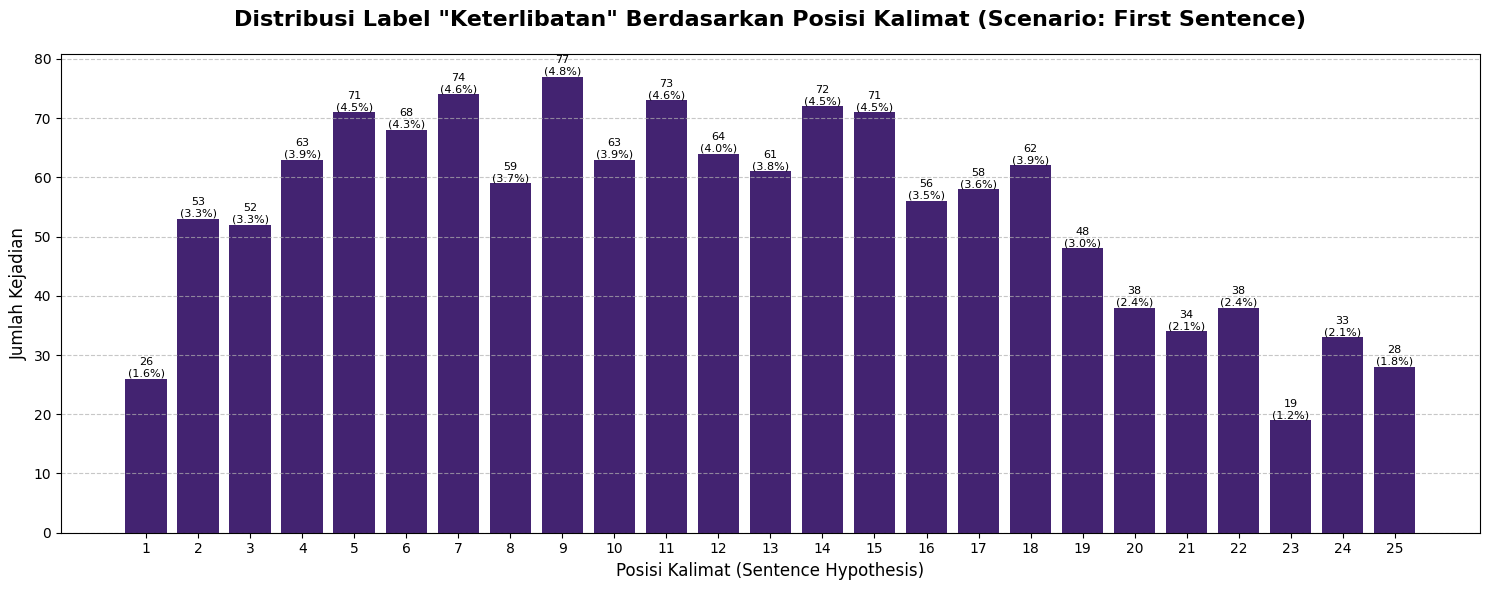


📊 ANALISIS CONFIDENCE SCORE (IndoBERT)
Rata-rata Confidence Score Global : 0.9283
Confidence Score Tertinggi        : 0.9967
Confidence Score Terendah         : 0.3411
----------------------------------------------------------------------

🔍 SAMPEL DETAIL ENTAILMENT (Top 50 Data):
╒═════════════╤══════════╤═══════════════╤═════════════════════════════════════════════════════════════════╕
│ Doc ID      │  Posisi  │  Conf. Score  │ Teks (Potongan)                                                 │
╞═════════════╪══════════╪═══════════════╪═════════════════════════════════════════════════════════════════╡
│ tempo_00001 │    12    │    0.9914     │ Koleksi yang ditampilkan                                        │
├─────────────┼──────────┼───────────────┼─────────────────────────────────────────────────────────────────┤
│ tempo_00001 │    35    │    0.9898     │ Transportasi                                                    │
├─────────────┼──────────┼───────────────┼─────────────────────

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import numpy as np

# ========================================================================
# 9. ANALISIS KOMPREHENSIF (VISUALISASI & TABEL)
# ========================================================================

if results:
    all_positions = []
    all_scores = []
    detailed_rows = []
    
    for res in results:
        for detail in res['entailment_details']:
            all_positions.append(detail['position'])
            all_scores.append(detail['score'])
            
            if len(detailed_rows) < 50: 
                detailed_rows.append([
                    res['doc_id'],
                    detail['position'],
                    f"{detail['score']:.4f}",
                    (detail['text'][:60] + '...') if len(detail['text']) > 60 else detail['text']
                ])

    plt.figure(figsize=(15, 6))
    
    pos_counts = pd.Series(all_positions).value_counts().sort_index()
    
    max_pos_plot = 25
    pos_counts_limited = pos_counts[pos_counts.index <= max_pos_plot]
    
    bars = plt.bar(pos_counts_limited.index, pos_counts_limited.values, color='#432371')
    
    plt.title('Distribusi Label "Keterlibatan" Berdasarkan Posisi Kalimat (Scenario: First Sentence)', fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Posisi Kalimat (Sentence Hypothesis)', fontsize=12)
    plt.ylabel('Jumlah Kejadian', fontsize=12)
    plt.xticks(range(1, max_pos_plot + 1))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    total_ent = len(all_positions)
    for bar in bars:
        height = bar.get_height()
        pct = (height / total_ent) * 100
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

    print("\n" + "="*70)
    print("📊 ANALISIS CONFIDENCE SCORE (IndoBERT)")
    print("="*70)
    if all_scores:
        print(f"Rata-rata Confidence Score Global : {np.mean(all_scores):.4f}")
        print(f"Confidence Score Tertinggi        : {np.max(all_scores):.4f}")
        print(f"Confidence Score Terendah         : {np.min(all_scores):.4f}")
    else:
        print("Data score kosong.")
    print("-"*70)
    
    print("\n🔍 SAMPEL DETAIL ENTAILMENT (Top 50 Data):")
    print(tabulate(
        detailed_rows, 
        headers=["Doc ID", "Posisi", "Conf. Score", "Teks (Potongan)"],
        tablefmt="fancy_grid",
        colalign=("left", "center", "center", "left")
    ))
    
else:
    print("⚠️ Data kosong, tidak bisa membuat visualisasi.")